In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
factories = pd.read_csv("Candy_Factories.csv")
products = pd.read_csv("Candy_Products.csv")
sales = pd.read_csv("Candy_Sales.csv")
targets = pd.read_csv("Candy_Targets.csv")
uszips = pd.read_csv("uszips.csv")

In [4]:
factories.rename(columns={
    'Factory': 'factory_name',
    'Latitude': 'factory_latitude',
    'Longitude': 'factory_longitude'
}, inplace=True)

In [5]:
products.rename(columns= {
    'Division' : 'product_category',
    'Product Name' : 'product_name',
    'Unit Price' : 'unit_price',
    'Unit Cost' : 'unit_price',
}, inplace=True)

In [6]:
sales.rename(columns={
    'Order ID': 'order_id',
    'Order Date': 'order_date',
    'Ship Date': 'ship_date',
    'Customer Name': 'customer_name',
    'City': 'customer_city',
    'State': 'customer_state',
    'ZIP': 'customer_zip',
    'Product Name': 'product_name',
    'Division': 'product_category',
    'Units': 'quantity_sold',
    'Sales': 'sales_amount',
    'Cost': 'total_cost',
    'Profit': 'profit',
    'Factory': 'factory_name'
}, inplace=True)

In [7]:
targets.rename(columns={
    'Division': 'product_category',
    'Target': 'sales_target'
}, inplace=True)

In [8]:
uszips.rename(columns={
    'zip': 'zip_code',
    'lat': 'latitude',
    'lng': 'longitude',
    'state_id': 'state_code',
    'state_name': 'state_name'
}, inplace=True)

In [9]:
print(factories.columns)
print(products.columns)
print(sales.columns)
print(targets.columns)
print(uszips.columns)

Index(['factory_name', 'factory_latitude', 'factory_longitude'], dtype='str')
Index(['product_category', 'product_name', 'Factory', 'Product ID',
       'unit_price', 'unit_price'],
      dtype='str')
Index(['Row ID', 'order_id', 'order_date', 'ship_date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'customer_city', 'State/Province',
       'Postal Code', 'product_category', 'Region', 'Product ID',
       'product_name', 'sales_amount', 'quantity_sold', 'Gross Profit',
       'total_cost'],
      dtype='str')
Index(['product_category', 'sales_target'], dtype='str')
Index(['zip_code', 'latitude', 'longitude', 'city', 'state_code', 'state_name',
       'zcta', 'population', 'density', 'county_fips', 'county_name',
       'county_weights', 'county_names_all', 'county_fips_all', 'imprecise',
       'military', 'timezone'],
      dtype='str')


In [17]:
sales.isnull().sum()

Row ID              0
order_id            0
order_date          0
ship_date           0
Ship Mode           0
Customer ID         0
Country/Region      0
customer_city       0
State/Province      0
Postal Code         0
product_category    0
Region              0
Product ID          0
product_name        0
sales_amount        0
quantity_sold       0
Gross Profit        0
total_cost          0
dtype: int64

In [18]:
products.isnull().sum()

product_category    0
product_name        0
Factory             0
Product ID          0
unit_price          0
unit_price          0
dtype: int64

In [19]:
factories.isnull().sum()

factory_name         0
factory_latitude     0
factory_longitude    0
dtype: int64

In [20]:
targets.isnull().sum()

product_category    0
sales_target        0
dtype: int64

In [14]:
uszips.isnull().sum()

zip_code             0
latitude             0
longitude            0
city                 0
state_code           0
state_name           0
zcta                 0
population          17
density             17
county_fips          0
county_name          0
county_weights       0
county_names_all     0
county_fips_all      0
imprecise            0
military             0
timezone             0
dtype: int64

In [21]:
uszips.isnull().sum()

zip_code             0
latitude             0
longitude            0
city                 0
state_code           0
state_name           0
zcta                 0
population          17
density             17
county_fips          0
county_name          0
county_weights       0
county_names_all     0
county_fips_all      0
imprecise            0
military             0
timezone             0
dtype: int64

In [22]:
sales.duplicated().sum()
products.duplicated().sum()
uszips.duplicated().sum()
factories.duplicated().sum()
targets.duplicated().sum()

np.int64(0)

In [23]:
sales['order_date']= pd.to_datetime(sales['order_date'])
sales['ship_date'] = pd.to_datetime(sales['ship_date'])

<!-- Correct Column Cleaning Sales -->

Correct Column Cleaning

In [24]:
sales.columns = sales.columns.str.strip().str.lower().str.replace(" ","_").str.replace("/","_")

print(sales.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country_region', 'customer_city', 'state_province',
       'postal_code', 'product_category', 'region', 'product_id',
       'product_name', 'sales_amount', 'quantity_sold', 'gross_profit',
       'total_cost'],
      dtype='str')


Product wise Total Revenue  Genarate from sales

In [25]:
product_revenue = sales.groupby("product_name")["sales_amount"].sum()

print(product_revenue.sort_values(ascending=False).head())

product_name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Name: sales_amount, dtype: float64


Average Quantity

In [26]:
avg_qty_product = sales.groupby("product_name")["quantity_sold"].mean().round()

print(avg_qty_product.sort_values(ascending=False).head())

product_name
Everlasting Gobstopper    4.0
Fizzy Lifting Drinks      4.0
Hair Toffee               4.0
Lickable Wallpaper        4.0
Kazookles                 4.0
Name: quantity_sold, dtype: float64


High Profit Orders WITH Product Name

In [27]:
result = high_profit_df.groupby("product_name")["gross_profit"].mean().reset_index().head(1).round()

print(result.sort_values(by="gross_profit", ascending=False ))

NameError: name 'high_profit_df' is not defined

Profit Trend WITH Product Name

In [ ]:
sales["profit_change"] = sales["gross_profit"].diff()

print(sales[["product_name", "gross_profit", "profit_change"]].head())

Top 5 Sales WITH Product Name

In [ ]:
top5_sales = sales.sort_values(by="sales_amount", ascending=False).head(5)

print(top5_sales[["product_name", "sales_amount"]])

Top Selling Product

In [28]:
top_product = sales.groupby("product_name")["quantity_sold"].sum().sort_values(ascending=False).head(5)

print(top_product)

product_name
Wonka Bar - Milk Chocolate           8267
Wonka Bar -Scrumdiddlyumptious       7743
Wonka Bar - Triple Dazzle Caramel    7596
Wonka Bar - Fudge Mallows            6914
Wonka Bar - Nutty Crunch Surprise    6755
Name: quantity_sold, dtype: int64


Total Revenue by Region

In [29]:
region_sales = sales.groupby("region")["sales_amount"].sum().sort_values(ascending=False)

print(region_sales)

region
Pacific     46301.53
Atlantic    41197.24
Interior    32037.60
Gulf        22247.26
Name: sales_amount, dtype: float64


Profit by Category

In [30]:
category_profit = sales.groupby("product_category")["gross_profit"].sum()

print(category_profit)

product_category
Chocolate    88824.62
Other         4333.45
Sugar          284.73
Name: gross_profit, dtype: float64


Monthly Sales Trend

In [31]:
sales["month"] = sales["order_date"].dt.month
sales["month_name"] = sales["order_date"].dt.month_name()

monthly_sales = sales.groupby(["month", "month_name"])["sales_amount"].sum().reset_index()

monthly_sales = monthly_sales.sort_values("month")

print(monthly_sales[["month_name", "sales_amount"]])

   month_name  sales_amount
0     January       5583.00
1    February       3933.52
2       March       9562.14
3       April       8910.66
4         May      10507.20
5        June       9733.69
6        July       9923.05
7      August      10217.75
8   September      19369.70
9     October      12161.87
10   November      20646.57
11   December      21234.48


Top Cities by Sales

In [32]:
city_sales = sales.groupby("customer_city")["sales_amount"].sum().sort_values(ascending=False).head(5).round()

print(city_sales)

customer_city
New York City    12515.0
Los Angeles      10409.0
Philadelphia      7416.0
San Francisco     7019.0
Seattle           5893.0
Name: sales_amount, dtype: float64


Monthly Revenue Trend

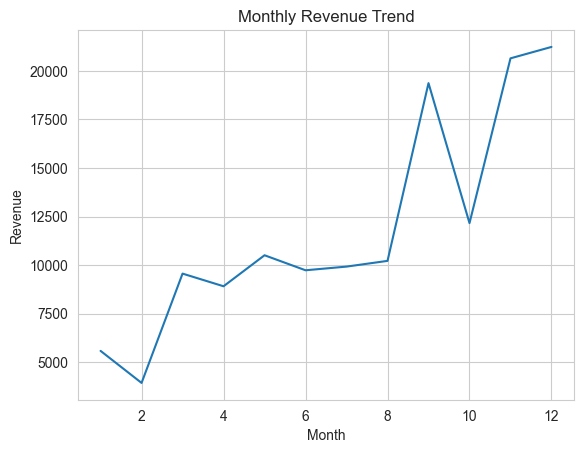

In [33]:
sales["order_date"] = pd.to_datetime(sales["order_date"])

monthly_sales = sales.groupby(sales["order_date"].dt.month)["sales_amount"].sum()

plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Top 5 Products

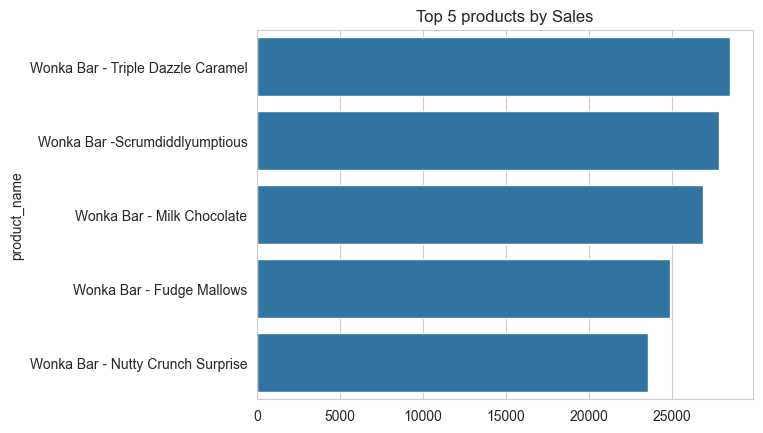

In [34]:
top_product =  sales.groupby('product_name')['sales_amount'].sum()

top_product = top_product.sort_values(ascending=False)

top_product = top_product.head(5)

sns.barplot(x = top_product.values , y= top_product.index)
plt.title("Top 5 products by Sales")
plt.show()

Region-wise Sales Distribution

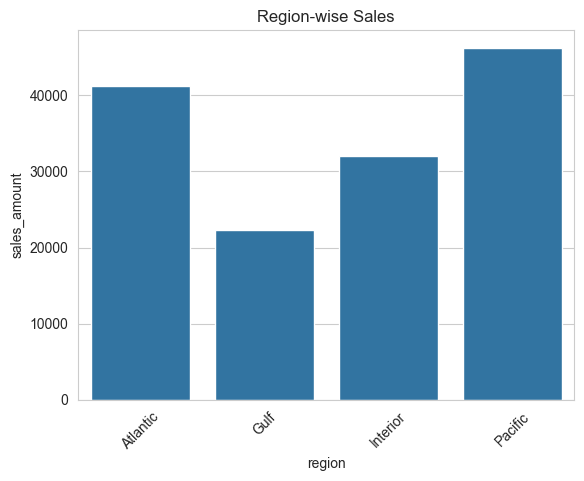

In [35]:
region_sales = sales.groupby("region")["sales_amount"].sum().reset_index()

sns.barplot(x="region", y="sales_amount", data=region_sales)
plt.title("Region-wise Sales")
plt.xticks(rotation=45)
plt.show()

Profit Distribution (Histogram)

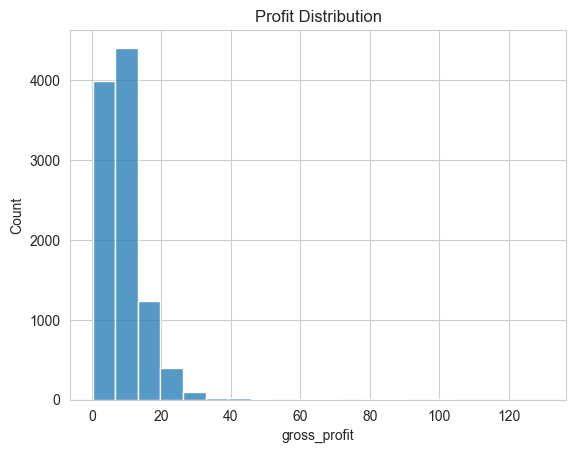

In [36]:
sns.histplot(sales["gross_profit"], bins=20)
plt.title("Profit Distribution")
plt.show()

Correlation Heatmap

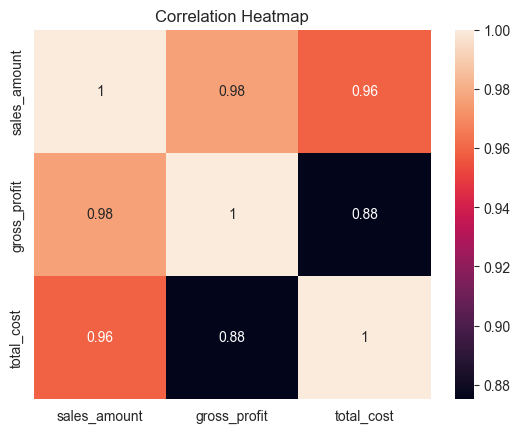

In [37]:
corr = sales[["sales_amount", "gross_profit", "total_cost"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()